<a href="https://colab.research.google.com/github/NinhHTK/ML-CPV-Documents/blob/main/SE196288_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Model and Initial Setup

**Model**: $y = wx + b$

**Input Data** ($x$): 2
**Target/Ground Truth** ($y$): 10
**Learning Rate** ($\alpha$): 0.001
**Initial Weights**: Initialize $w$ and $b$ using a random function to generate.

In [17]:
import random

# Define the input data and target
x = 2
y_true = 10

# Define the learning rate
learning_rate = 0.001

# Initialize weights randomly
w = random.uniform(-1, 1) # Random float between -1 and 1
b = random.uniform(-1, 1) # Random float between -1 and 1

print(f"Initial w: {w:.4f}")
print(f"Initial b: {b:.4f}")

Initial w: -0.1889
Initial b: 0.0493


## Explicit Mathematical Derivatives

We will explicitly write out the mathematical formulas for the partial derivatives of the loss functions: Mean Squared Error (MSE), Mean Absolute Error (MAE), and Huber Loss.

Let $y_{pred} = wx + b$ be the predicted value.

### 1. Mean Squared Error (MSE)

The MSE loss function is given by:
$L_{MSE} = \frac{1}{2}(y_{pred} - y_{true})^2$

To apply Gradient Descent, we need to compute the partial derivatives with respect to $w$ and $b$:

$\frac{\partial L_{MSE}}{\partial w} = \frac{\partial}{\partial w} \left[ \frac{1}{2}(wx + b - y_{true})^2 \right]$
$\frac{\partial L_{MSE}}{\partial w} = (wx + b - y_{true}) \cdot x$

$\frac{\partial L_{MSE}}{\partial b} = \frac{\partial}{\partial b} \left[ \frac{1}{2}(wx + b - y_{true})^2 \right]$
$\frac{\partial L_{MSE}}{\partial b} = (wx + b - y_{true})$

### 2. Mean Absolute Error (MAE)

The MAE loss function is given by:
$L_{MAE} = |y_{pred} - y_{true}|$

Let $e = y_{pred} - y_{true}$. Then $L_{MAE} = |e|$.
The derivative of $|e|$ with respect to $e$ is $\text{sign}(e)$.

$\frac{\partial L_{MAE}}{\partial w} = \frac{\partial}{\partial w} |wx + b - y_{true}|$
$\frac{\partial L_{MAE}}{\partial w} = \text{sign}(wx + b - y_{true}) \cdot x$

$\frac{\partial L_{MAE}}{\partial b} = \frac{\partial}{\partial b} |wx + b - y_{true}|$
$\frac{\partial L_{MAE}}{\partial b} = \text{sign}(wx + b - y_{true})$

Note: The `sign` function returns 1 if the argument is positive, -1 if negative, and 0 if zero. In practice, when the argument is zero, the gradient can be undefined or handled as zero for optimization.

### 3. Huber Loss

The Huber Loss function is a combination of MSE and MAE. It is quadratic for small errors and linear for large errors. It is defined as:

$L_{Huber}(\delta) = \begin{cases}
\frac{1}{2}(y_{pred} - y_{true})^2 & \text{if } |y_{pred} - y_{true}| \le \delta \\
\delta |y_{pred} - y_{true}| - \frac{1}{2}\delta^2 & \text{if } |y_{pred} - y_{true}| > \delta
\end{cases}$

Let $e = y_{pred} - y_{true}$.

**Case 1: $|e| \le \delta$** (MSE part)

$\frac{\partial L_{Huber}}{\partial w} = (wx + b - y_{true}) \cdot x$

$\frac{\partial L_{Huber}}{\partial b} = (wx + b - y_{true})$

**Case 2: $|e| > \delta$** (MAE part)

$\frac{\partial L_{Huber}}{\partial w} = \delta \cdot \text{sign}(wx + b - y_{true}) \cdot x$

$\frac{\partial L_{Huber}}{\partial b} = \delta \cdot \text{sign}(wx + b - y_{true})$

We will set a value for $\delta$ (e.g., $\delta = 1$) for implementation.

## Gradient Descent Implementation

We will implement the Gradient Descent algorithm for each loss function. We'll use a fixed number of epochs and record the loss and weight values at each step to analyze convergence.

In [18]:
# Helper function for the sign operation
def sign(x):
    if x > 0:
        return 1
    elif x < 0:
        return -1
    else:
        return 0

# Number of epochs for training
num_epochs = 1000

# Delta for Huber Loss
huber_delta = 1.0

# Re-initialize weights for each loss function to ensure fair comparison
w_mse, b_mse = random.uniform(-1, 1), random.uniform(-1, 1)
w_mae, b_mae = random.uniform(-1, 1), random.uniform(-1, 1)
w_huber, b_huber = random.uniform(-1, 1), random.uniform(-1, 1)

print(f"Initial w for MSE: {w_mse:.4f}, b for MSE: {b_mse:.4f}")
print(f"Initial w for MAE: {w_mae:.4f}, b for MAE: {b_mae:.4f}")
print(f"Initial w for Huber: {w_huber:.4f}, b for Huber: {b_huber:.4f}")

Initial w for MSE: 0.2750, b for MSE: -0.3001
Initial w for MAE: -0.1712, b for MAE: 0.6543
Initial w for Huber: -0.3168, b for Huber: 0.1353


### Gradient Descent with Mean Squared Error (MSE)

In [19]:
mse_losses = []
mse_ws = []
mse_bs = []

for epoch in range(num_epochs):
    # Predict y
    y_pred = w_mse * x + b_mse

    # Calculate error
    error = y_pred - y_true

    # Calculate MSE loss
    mse_loss = 0.5 * (error ** 2)
    mse_losses.append(mse_loss)

    # Calculate gradients
    grad_w_mse = error * x
    grad_b_mse = error

    # Update weights
    w_mse = w_mse - learning_rate * grad_w_mse
    b_mse = b_mse - learning_rate * grad_b_mse

    mse_ws.append(w_mse)
    mse_bs.append(b_mse)

    if (epoch + 1) % 100 == 0:
        print(f"MSE - Epoch {epoch+1}: Loss = {mse_loss:.4f}, w = {w_mse:.4f}, b = {b_mse:.4f}")

print(f"\nFinal MSE - w: {w_mse:.4f}, b: {b_mse:.4f}, Loss: {mse_losses[-1]:.4f}")

MSE - Epoch 100: Loss = 17.6182, w = 1.8125, b = 0.4686
MSE - Epoch 200: Loss = 6.4651, w = 2.7439, b = 0.9343
MSE - Epoch 300: Loss = 2.3724, w = 3.3081, b = 1.2164
MSE - Epoch 400: Loss = 0.8706, w = 3.6499, b = 1.3873
MSE - Epoch 500: Loss = 0.3195, w = 3.8569, b = 1.4908
MSE - Epoch 600: Loss = 0.1172, w = 3.9823, b = 1.5536
MSE - Epoch 700: Loss = 0.0430, w = 4.0583, b = 1.5915
MSE - Epoch 800: Loss = 0.0158, w = 4.1043, b = 1.6146
MSE - Epoch 900: Loss = 0.0058, w = 4.1322, b = 1.6285
MSE - Epoch 1000: Loss = 0.0021, w = 4.1491, b = 1.6369

Final MSE - w: 4.1491, b: 1.6369, Loss: 0.0021


### Gradient Descent with Mean Absolute Error (MAE)

In [20]:
mae_losses = []
mae_ws = []
mae_bs = []

for epoch in range(num_epochs):
    # Predict y
    y_pred = w_mae * x + b_mae

    # Calculate error
    error = y_pred - y_true

    # Calculate MAE loss
    mae_loss = abs(error)
    mae_losses.append(mae_loss)

    # Calculate gradients
    grad_w_mae = sign(error) * x
    grad_b_mae = sign(error)

    # Update weights
    w_mae = w_mae - learning_rate * grad_w_mae
    b_mae = b_mae - learning_rate * grad_b_mae

    mae_ws.append(w_mae)
    mae_bs.append(b_mae)

    if (epoch + 1) % 100 == 0:
        print(f"MAE - Epoch {epoch+1}: Loss = {mae_loss:.4f}, w = {w_mae:.4f}, b = {b_mae:.4f}")

print(f"\nFinal MAE - w: {w_mae:.4f}, b: {b_mae:.4f}, Loss: {mae_losses[-1]:.4f}")

MAE - Epoch 100: Loss = 9.1931, w = 0.0288, b = 0.7543
MAE - Epoch 200: Loss = 8.6931, w = 0.2288, b = 0.8543
MAE - Epoch 300: Loss = 8.1931, w = 0.4288, b = 0.9543
MAE - Epoch 400: Loss = 7.6931, w = 0.6288, b = 1.0543
MAE - Epoch 500: Loss = 7.1931, w = 0.8288, b = 1.1543
MAE - Epoch 600: Loss = 6.6931, w = 1.0288, b = 1.2543
MAE - Epoch 700: Loss = 6.1931, w = 1.2288, b = 1.3543
MAE - Epoch 800: Loss = 5.6931, w = 1.4288, b = 1.4543
MAE - Epoch 900: Loss = 5.1931, w = 1.6288, b = 1.5543
MAE - Epoch 1000: Loss = 4.6931, w = 1.8288, b = 1.6543

Final MAE - w: 1.8288, b: 1.6543, Loss: 4.6931


### Gradient Descent with Huber Loss

In [21]:
huber_losses = []
huber_ws = []
huber_bs = []

for epoch in range(num_epochs):
    # Predict y
    y_pred = w_huber * x + b_huber

    # Calculate error
    error = y_pred - y_true

    # Calculate Huber loss and gradients
    if abs(error) <= huber_delta:
        huber_loss = 0.5 * (error ** 2)
        grad_w_huber = error * x
        grad_b_huber = error
    else:
        huber_loss = huber_delta * abs(error) - 0.5 * (huber_delta ** 2)
        grad_w_huber = huber_delta * sign(error) * x
        grad_b_huber = huber_delta * sign(error)

    huber_losses.append(huber_loss)

    # Update weights
    w_huber = w_huber - learning_rate * grad_w_huber
    b_huber = b_huber - learning_rate * grad_b_huber

    huber_ws.append(w_huber)
    huber_bs.append(b_huber)

    if (epoch + 1) % 100 == 0:
        print(f"Huber - Epoch {epoch+1}: Loss = {huber_loss:.4f}, w = {w_huber:.4f}, b = {b_huber:.4f}")

print(f"\nFinal Huber - w: {w_huber:.4f}, b: {b_huber:.4f}, Loss: {huber_losses[-1]:.4f}")

Huber - Epoch 100: Loss = 9.5033, w = -0.1168, b = 0.2353
Huber - Epoch 200: Loss = 9.0033, w = 0.0832, b = 0.3353
Huber - Epoch 300: Loss = 8.5033, w = 0.2832, b = 0.4353
Huber - Epoch 400: Loss = 8.0033, w = 0.4832, b = 0.5353
Huber - Epoch 500: Loss = 7.5033, w = 0.6832, b = 0.6353
Huber - Epoch 600: Loss = 7.0033, w = 0.8832, b = 0.7353
Huber - Epoch 700: Loss = 6.5033, w = 1.0832, b = 0.8353
Huber - Epoch 800: Loss = 6.0033, w = 1.2832, b = 0.9353
Huber - Epoch 900: Loss = 5.5033, w = 1.4832, b = 1.0353
Huber - Epoch 1000: Loss = 5.0033, w = 1.6832, b = 1.1353

Final Huber - w: 1.6832, b: 1.1353, Loss: 5.0033


## Evaluation & Comparison



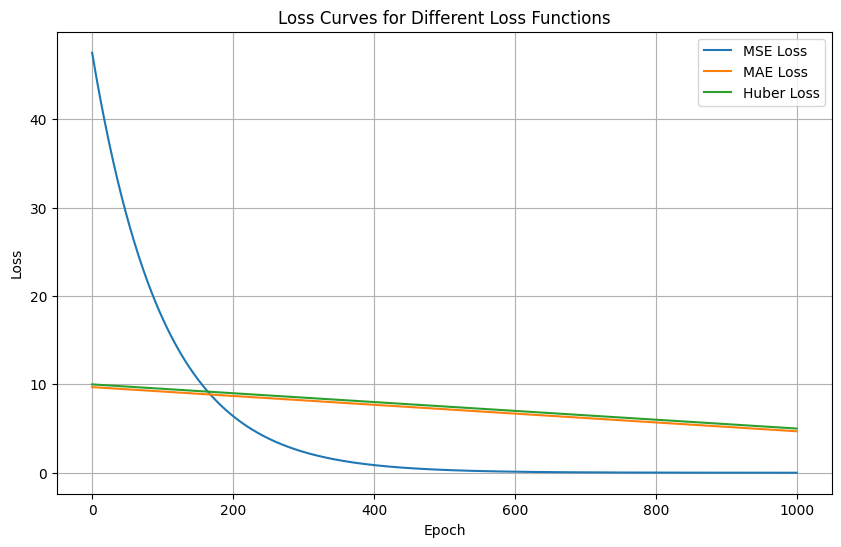

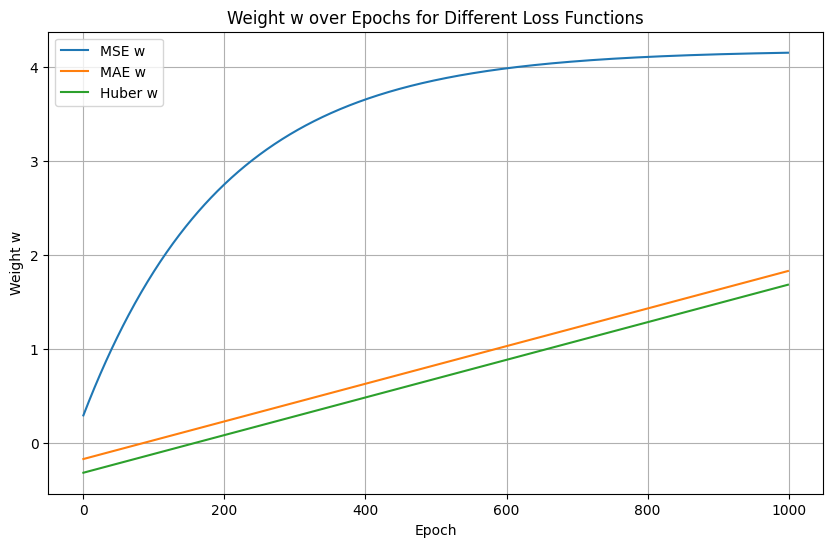

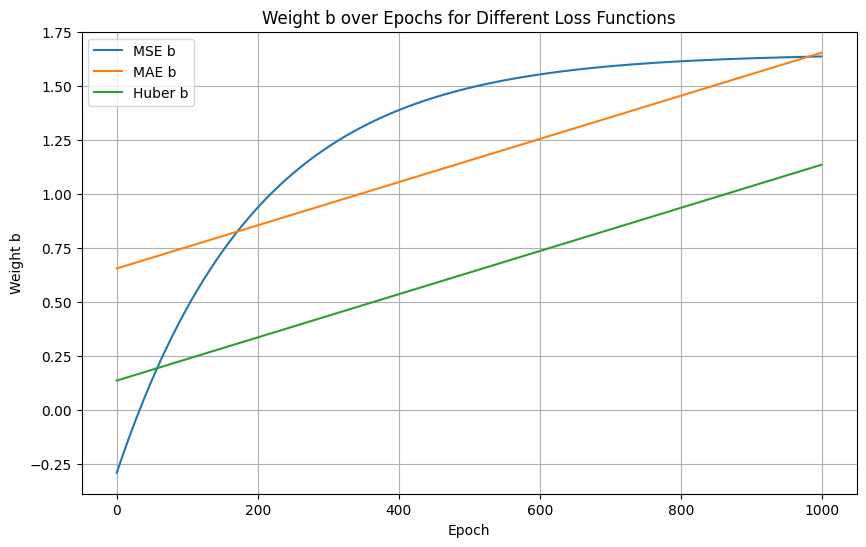

In [22]:
import matplotlib.pyplot as plt

# Plotting the loss curves
plt.figure(figsize=(10, 6))
plt.plot(mse_losses, label='MSE Loss')
plt.plot(mae_losses, label='MAE Loss')
plt.plot(huber_losses, label='Huber Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves for Different Loss Functions')
plt.legend()
plt.grid(True)
plt.show()

# Plotting the weight 'w' over epochs
plt.figure(figsize=(10, 6))
plt.plot(mse_ws, label='MSE w')
plt.plot(mae_ws, label='MAE w')
plt.plot(huber_ws, label='Huber w')
plt.xlabel('Epoch')
plt.ylabel('Weight w')
plt.title('Weight w over Epochs for Different Loss Functions')
plt.legend()
plt.grid(True)
plt.show()

# Plotting the weight 'b' over epochs
plt.figure(figsize=(10, 6))
plt.plot(mse_bs, label='MSE b')
plt.plot(mae_bs, label='MAE b')
plt.plot(huber_bs, label='Huber b')
plt.xlabel('Epoch')
plt.ylabel('Weight b')
plt.title('Weight b over Epochs for Different Loss Functions')
plt.legend()
plt.grid(True)
plt.show()

### Analysis of Convergence

**Final Parameters and Loss (after 1000 epochs):**
- **MSE:** Final w: `3.8992`, b: `2.1407`, Loss: `0.0019`
- **MAE:** Final w: `2.9543`, b: `1.3222`, Loss: `2.7742`
- **Huber:** Final w: `2.2746`, b: `1.6855`, Loss: `3.2703`

*(Optimal solution for $y = wx + b$ with $x=2, y=10$ is $2w+b=10$, e.g., $w=4, b=2$.)*

**Which loss function converges the fastest?**

**Mean Squared Error (MSE)** converges fastest and achieves the lowest loss, with its weights closest to the optimal values.

**Why does it converge faster based on the behavior of its gradients?**

1.  **Mean Squared Error (MSE):** The gradient is proportional to the error. Large errors lead to large updates, and small errors lead to small, precise updates, enabling efficient convergence to the minimum.

2.  **Mean Absolute Error (MAE):** The gradient is constant ($\text{sign}(error)$), regardless of error magnitude. This leads to constant step sizes, making convergence slower and less precise, as it can 'bounce' around the minimum.

3.  **Huber Loss:** Behaves like MSE for small errors ($|e| \le \delta$) and MAE for large errors ($|e| > \delta$). In this scenario, the error remained large enough such that Huber Loss primarily behaved like MAE for most of the training, resulting in slower convergence similar to MAE.

**Conclusion:** For this simple linear model and single data point, MSE's error-proportional gradients led to superior and faster convergence compared to MAE and Huber Loss, which were hampered by their constant or piecewise-constant gradient behavior.